# Feature Importance Analysis

Loads a trained ML model and answers three questions:

1. **Per-bottleneck** - which features drive each classifier?
2. **Global** - which features are most / least important across all classifiers?
3. **By statistic** - which statistical measures (mean, skewness, autocorrelation, ...) matter most?

**How to use**
1. Set `MODEL_PATH` in the Config cell below.
2. Run all cells (`Kernel -> Restart & Run All`).
3. Results are saved to `RESULTS_DIR` - previous runs are preserved.

In [1]:
# --- CONFIG - edit these ---------------------------------------------------------------------------------
MODEL_PATH  = "models/xgboost.pkl"                        # relative to repo root
TOP_N       = 20                                          # top N features shown in plots and saved
RESULTS_DIR = "results/"    # saved results directory
# ------------------------------------------------------------------------------------------------------------------─

In [2]:
import sys
import json
import math
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_repo_root = Path(__vsc_ipynb_file__).resolve().parent.parent
sys.path.insert(0, str(_repo_root / "src"))

MODEL_PATH_ABS  = _repo_root / MODEL_PATH
RESULTS_DIR_ABS = _repo_root / RESULTS_DIR

from hpc_bottleneck_detector.ml.backends.default_backend import DefaultBackend

print(f"Repo root : {_repo_root}")
print(f"Model     : {MODEL_PATH_ABS}")
print(f"Results   : {RESULTS_DIR_ABS}")

Repo root : /home/crippius/uni/master-thesis/hpc-bottleneck-detector
Model     : /home/crippius/uni/master-thesis/hpc-bottleneck-detector/models/xgboost.pkl
Results   : /home/crippius/uni/master-thesis/hpc-bottleneck-detector/results


## 1. Load Model

In [3]:
backend    = DefaultBackend.load(str(MODEL_PATH_ABS))
model_name = MODEL_PATH_ABS.stem

print(f"Model: {model_name}")
print(f"\nBottleneck types ({len(backend._models)}):")
for bt_name in backend._models:
    n_feat = len(backend._feature_cols[bt_name])
    print(f"  {bt_name:<45} {n_feat:>4} features")

Model: xgboost

Bottleneck types (6):
  PIPELINE_STALL                                  37 features
  COMPUTE_UNDERUTILIZATION                        50 features
  PRECISION_WASTE                                 38 features
  BRANCH_MISPREDICTION                            32 features
  CACHE_PRESSURE                                  58 features
  INTRA_NODE_LOAD_IMBALANCE                        2 features


/home/crippius/miniconda3/envs/thesisEnv/lib/python3.10/pickle.py:1718: UserWarning: [12:27:19] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125046773/work/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


## 2. Per-Bottleneck Feature Importance

Top `TOP_N` features for each bottleneck type, ranked by RandomForest `feature_importances_`.

In [4]:
importance_by_bt: dict[str, pd.DataFrame] = {}
for bt_name, clf in backend._models.items():
    df = (
        pd.DataFrame({
            "feature"   : backend._feature_cols[bt_name],
            "importance": clf.feature_importances_,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    importance_by_bt[bt_name] = df

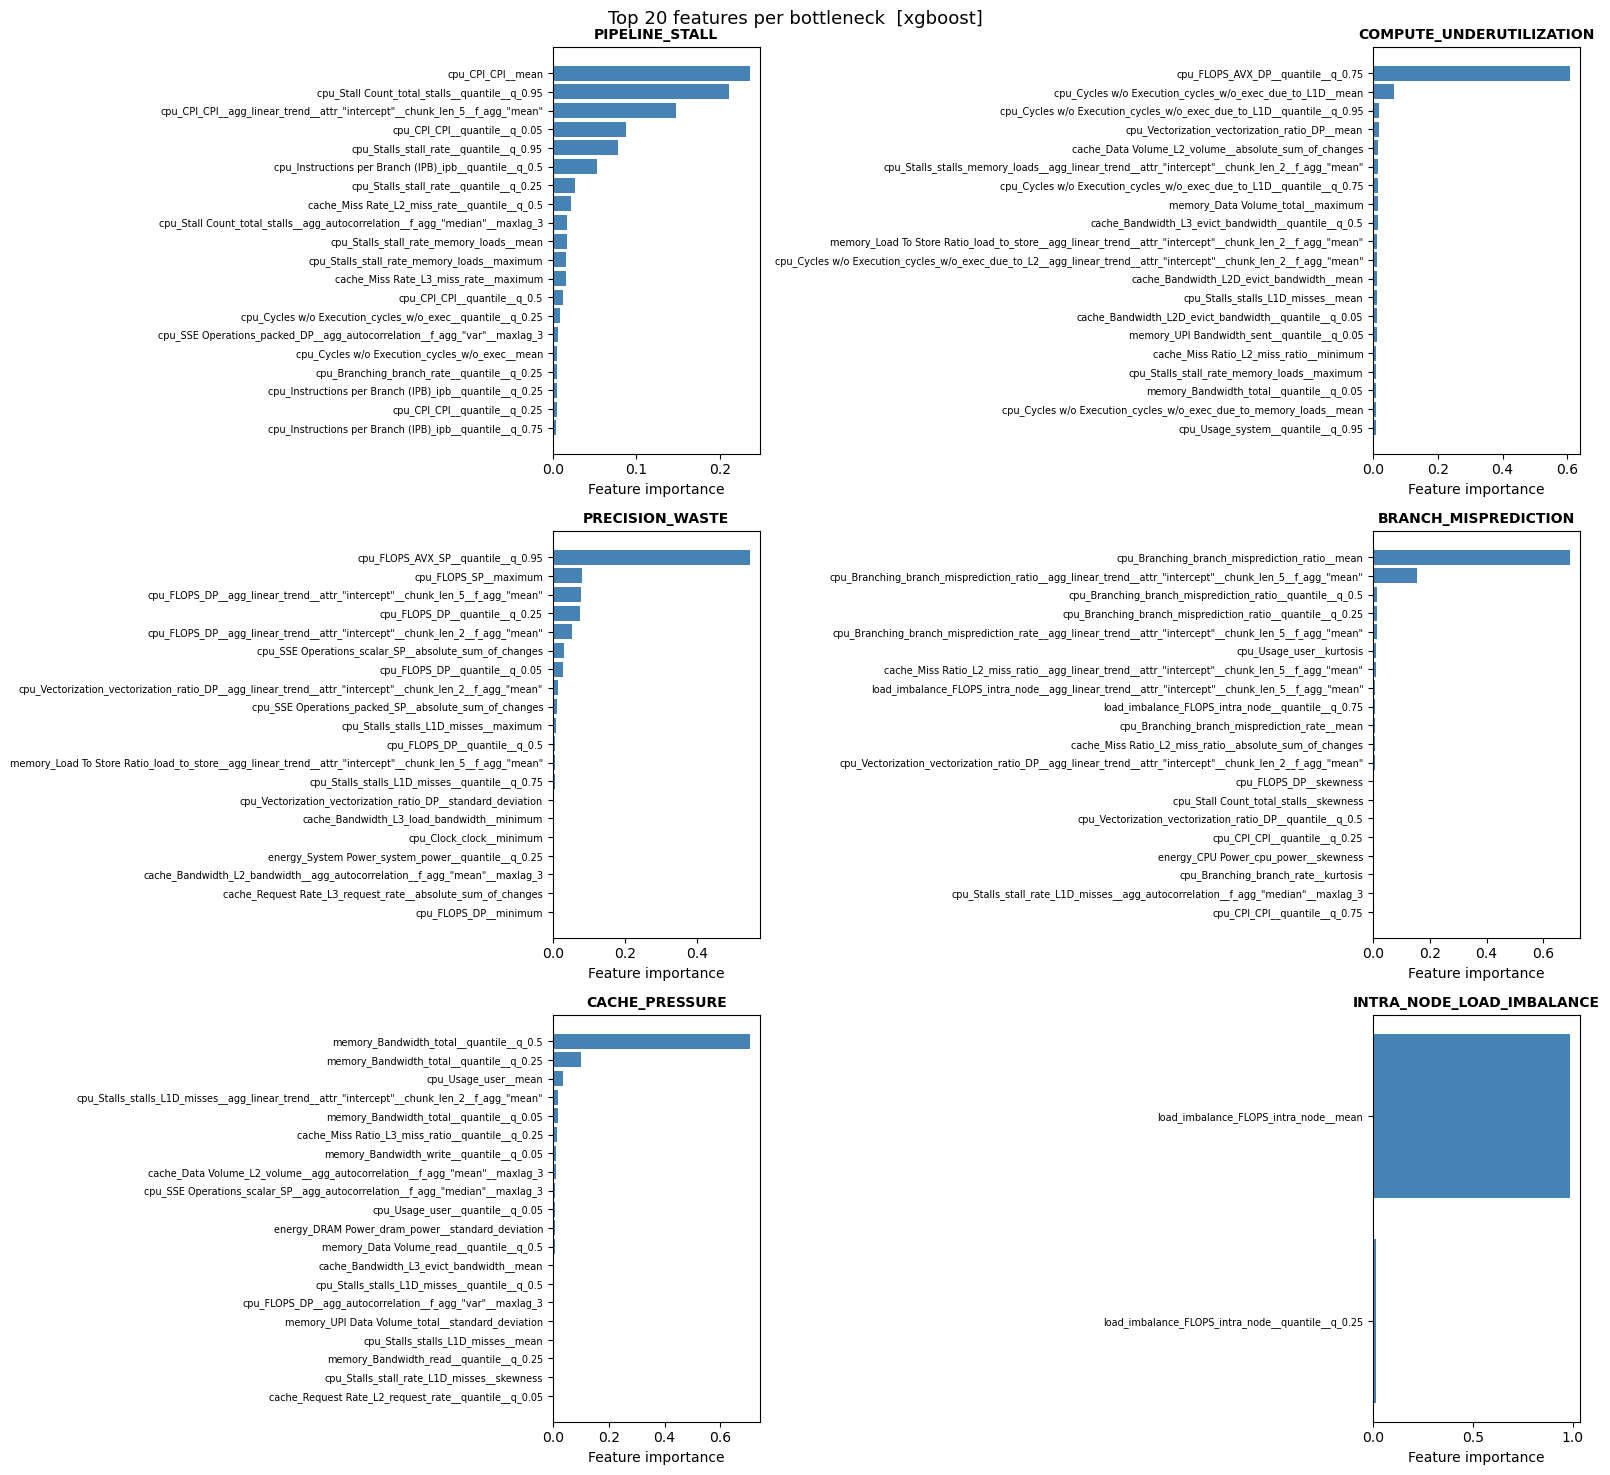

In [5]:
n_bt   = len(importance_by_bt)
n_cols = 2
n_rows = math.ceil(n_bt / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows), squeeze=False)
axes_flat = axes.flatten()

for i, (bt_name, df) in enumerate(importance_by_bt.items()):
    ax  = axes_flat[i]
    top = df.head(TOP_N)
    ax.barh(top["feature"][::-1], top["importance"][::-1], color="steelblue")
    ax.set_title(bt_name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Feature importance")
    ax.tick_params(axis="y", labelsize=7)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle(f"Top {TOP_N} features per bottleneck  [{model_name}]", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Metric Importance per Bottleneck

Top `TOP_N` hardware counter groups per bottleneck, with importance summed across all tsfresh transforms of each metric.

In [6]:
all_rows = []
for bt_name, df in importance_by_bt.items():
    tmp = df.copy()
    tmp["bottleneck"] = bt_name
    all_rows.append(tmp)

all_df = pd.concat(all_rows, ignore_index=True)

global_importance = (
    all_df.groupby("feature")["importance"]
    .agg(mean_importance="mean", max_importance="max", n_models="count")
    .reset_index()
    .sort_values("mean_importance", ascending=False)
    .reset_index(drop=True)
)

print(f"Unique features across all models: {len(global_importance)}")

Unique features across all models: 193


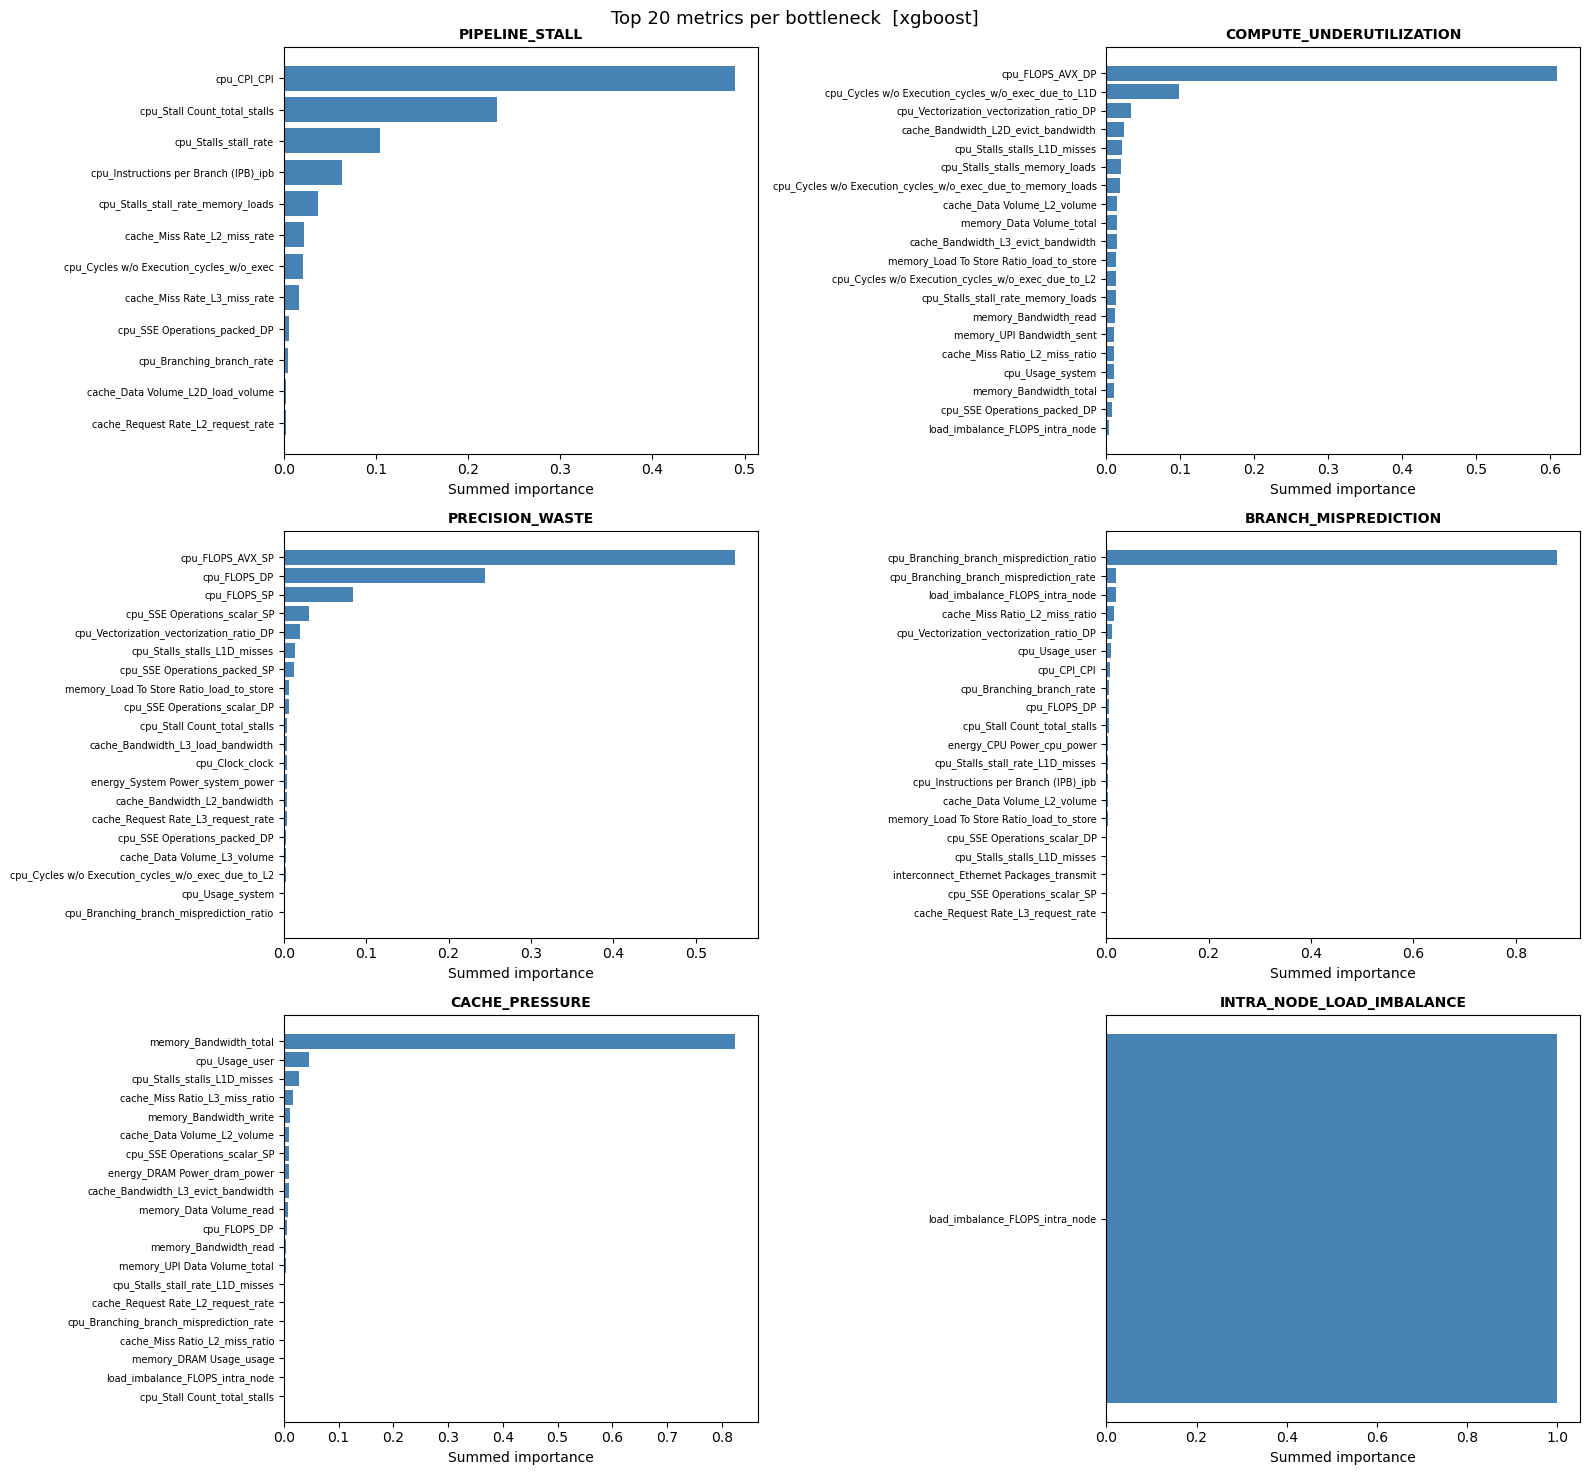

In [7]:
metric_importance_by_bt = {}
for bt_name, df in importance_by_bt.items():
    tmp = df.copy()
    tmp["metric"] = tmp["feature"].str.split("__").str[0]
    metric_importance_by_bt[bt_name] = (
        tmp.groupby("metric")["importance"]
        .sum()
        .reset_index()
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

n_bt   = len(metric_importance_by_bt)
n_cols = 2
n_rows = math.ceil(n_bt / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows), squeeze=False)
axes_flat = axes.flatten()

for i, (bt_name, df) in enumerate(metric_importance_by_bt.items()):
    ax  = axes_flat[i]
    top = df.head(TOP_N)
    ax.barh(top["metric"][::-1], top["importance"][::-1], color="steelblue")
    ax.set_title(bt_name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Summed importance")
    ax.tick_params(axis="y", labelsize=7)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle(f"Top {TOP_N} metrics per bottleneck  [{model_name}]", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Importance by statistical measure

tsfresh feature names follow the pattern `{metric}__{statistic}[__params]`.  
This section groups features by their statistic type and ranks them by mean importance -  
revealing which *kinds* of computation (mean, skewness, autocorrelation, ...) the models rely on most.

In [8]:
def _stat_base(feature_name: str) -> str:
    parts = feature_name.split("__")
    return parts[1] if len(parts) >= 2 else feature_name

def _stat_full(feature_name: str) -> str:
    parts = feature_name.split("__")
    return "__".join(parts[1:]) if len(parts) >= 2 else feature_name

all_df["stat_base"] = all_df["feature"].apply(_stat_base)
all_df["stat_full"] = all_df["feature"].apply(_stat_full)

stat_base_imp = (
    all_df.groupby("stat_base")["importance"]
    .agg(mean_importance="mean", total_importance="sum", n_features="count")
    .reset_index()
    .sort_values("mean_importance", ascending=False)
    .reset_index(drop=True)
)

stat_full_imp = (
    all_df.groupby(["stat_base", "stat_full"])["importance"]
    .agg(mean_importance="mean", total_importance="sum", n_features="count")
    .reset_index()
    .sort_values("mean_importance", ascending=False)
    .reset_index(drop=True)
)

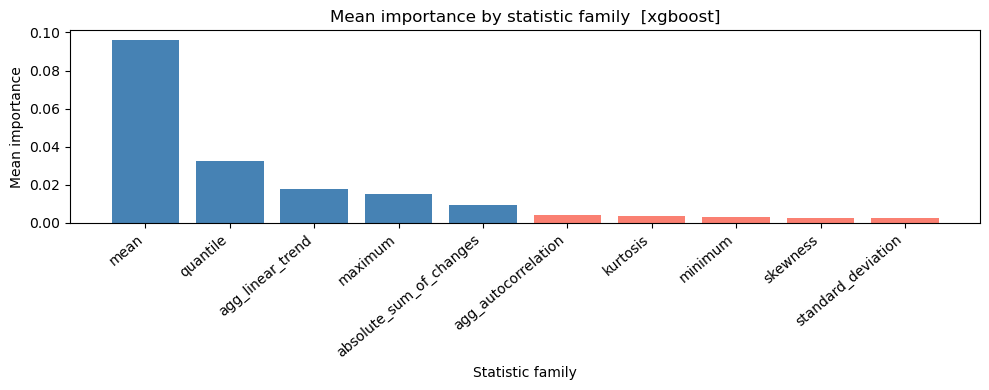

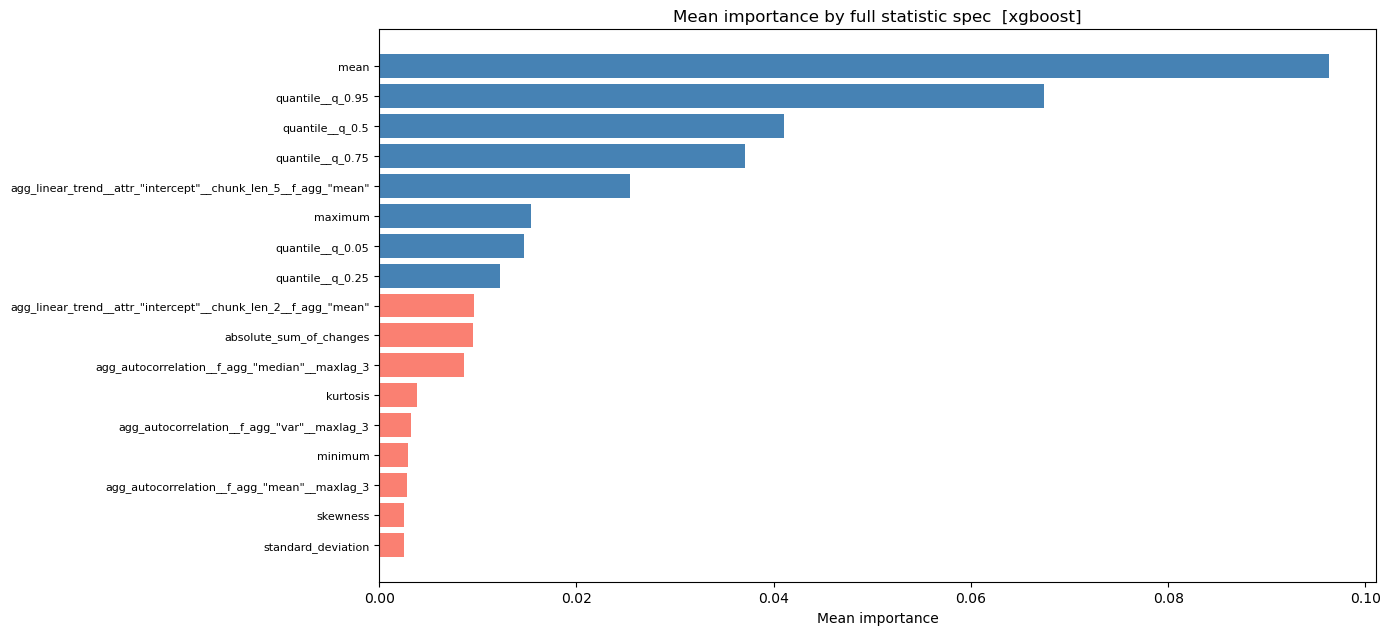

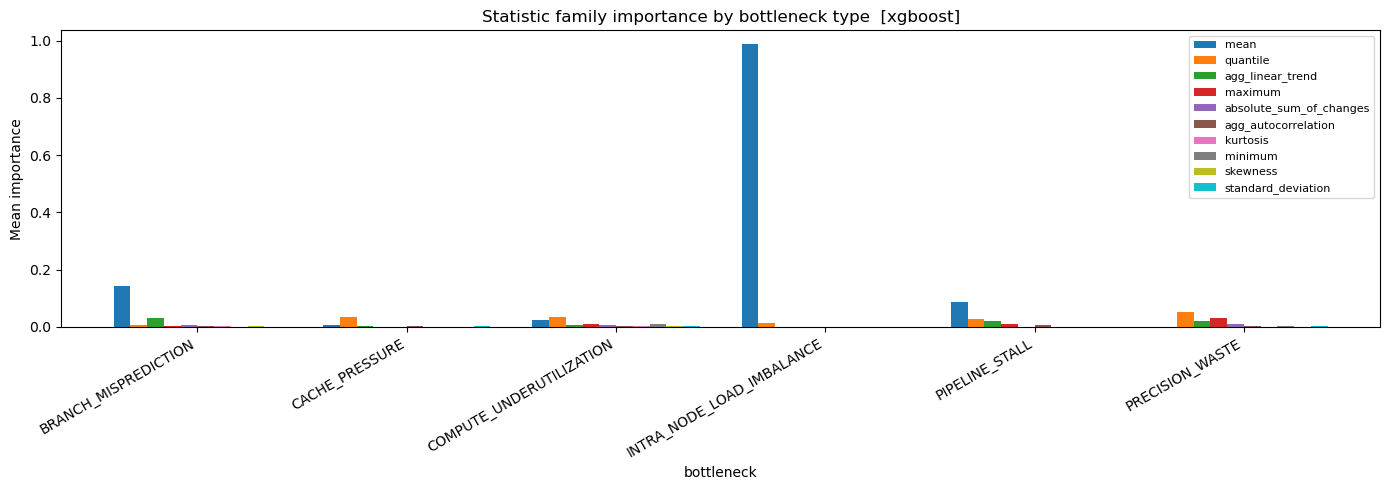

In [9]:
# --- 1. Statistic families (bar chart) ------------------------------------------------------------
n_base  = len(stat_base_imp)
mid     = n_base // 2
colors  = ["steelblue"] * mid + ["salmon"] * (n_base - mid)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(stat_base_imp["stat_base"], stat_base_imp["mean_importance"], color=colors)
ax.set_title(f"Mean importance by statistic family  [{model_name}]")
ax.set_xlabel("Statistic family")
ax.set_ylabel("Mean importance")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

# --- 2. Full specs - shows quantile q=0.05 vs q=0.95, trend slope vs intercept, ...
n_full   = len(stat_full_imp)
mid_f    = n_full // 2
colors_f = ["steelblue"] * mid_f + ["salmon"] * (n_full - mid_f)

fig, ax = plt.subplots(figsize=(14, max(5, n_full * 0.38)))
ax.barh(
    stat_full_imp["stat_full"][::-1],
    stat_full_imp["mean_importance"][::-1],
    color=colors_f[::-1],
)
ax.set_title(f"Mean importance by full statistic spec  [{model_name}]")
ax.set_xlabel("Mean importance")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

# --- 3. Per-bottleneck breakdown by family ------------------------------------------------------─
stat_per_bt = (
    all_df.groupby(["bottleneck", "stat_base"])["importance"]
    .mean()
    .unstack(fill_value=0.0)
    .reindex(columns=stat_base_imp["stat_base"])
)

stat_per_bt.plot(
    kind="bar",
    figsize=(14, 5),
    width=0.8,
    title=f"Statistic family importance by bottleneck type  [{model_name}]",
)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Mean importance")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 5. Save Results

Each run writes a timestamped JSON snapshot to `RESULTS_DIR`. Previous runs are preserved.

In [10]:
RESULTS_DIR_ABS.mkdir(parents=True, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_key   = f"{model_name}_{timestamp}"

results = {
    "run_key"   : run_key,
    "model_path": str(MODEL_PATH_ABS),
    "model_name": model_name,
    "timestamp" : timestamp,
    "per_bottleneck": {
        bt_name: {
            "n_features"  : len(df),
            "top_features": df.head(TOP_N)[["feature", "importance"]].to_dict("records"),
        }
        for bt_name, df in importance_by_bt.items()
    },
    "global": {
        "top_features": global_importance.head(TOP_N).to_dict("records"),
    },
    "statistics": {
        "by_family"   : stat_base_imp.to_dict("records"),
        "by_full_spec": stat_full_imp.to_dict("records"),
    },
}

out_path = RESULTS_DIR_ABS / f"{run_key}.json"
out_path.write_text(json.dumps(results, indent=2))
print(f"Saved: {out_path}")

Saved: /home/crippius/uni/master-thesis/hpc-bottleneck-detector/results/xgboost_20260625_122723.json
